<a href="https://colab.research.google.com/github/Spandana2704/ML/blob/main/ML_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes  # regression dataset
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [3]:
data = load_diabetes()
X = data.data
y = data.target

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
baseline_rf = RandomForestRegressor(random_state=42)
baseline_rf.fit(X_train, y_train)
y_pred_baseline = baseline_rf.predict(X_test)

In [6]:
baseline_mse = mean_squared_error(y_test, y_pred_baseline)
print("=== Baseline Random Forest ===")
print("Baseline Random Forest MSE:", baseline_mse)

=== Baseline Random Forest ===
Baseline Random Forest MSE: 2952.0105887640448


In [7]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_leaf': [1, 2, 5]
}

In [8]:
grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid,
                    cv=5,
                    scoring='neg_mean_squared_error',
                    verbose=2)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, n_estimators=50; total time=   0.1s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, n_estimators=50; total time=   0.1s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, n_estimators=50; total time=   0.2s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, n_estimators=50; total time=   0.1s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, n_estimators=50; total time=   0.1s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, n_estimators=100; total time=   0.3s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1,

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, 20, None],
                         'max_features': ['sqrt', 'log2', None],
                         'min_samples_leaf': [1, 2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_mean_squared_error', verbose=2)

In [9]:
print("\n=== Best Parameters Found ===")
print(grid.best_params_)


=== Best Parameters Found ===
{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}


In [10]:
best_rf = grid.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
tuned_mse = mean_squared_error(y_test, y_pred_tuned)
print("\n=== Tuned Random Forest ===")
print("Tuned Random Forest MSE:", tuned_mse)


=== Tuned Random Forest ===
Tuned Random Forest MSE: 2853.0919763137363


In [11]:
print("\n=== Performance Comparison ===")
print("Baseline MSE:", baseline_mse)
print("Tuned MSE:", tuned_mse)


=== Performance Comparison ===
Baseline MSE: 2952.0105887640448
Tuned MSE: 2853.0919763137363


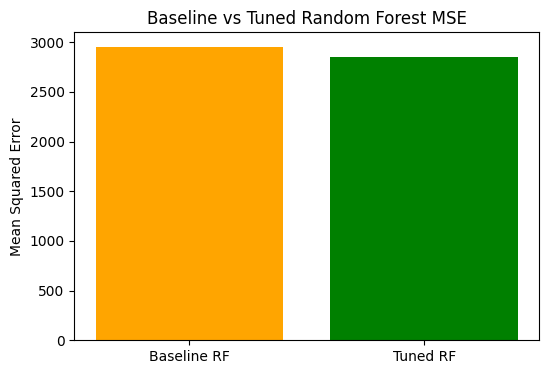

In [12]:
plt.figure(figsize=(6,4))
plt.bar(["Baseline RF", "Tuned RF"], [baseline_mse, tuned_mse], color=['orange', 'green'])
plt.title("Baseline vs Tuned Random Forest MSE")
plt.ylabel("Mean Squared Error")
plt.show()